In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [165]:
df = pd.read_csv("laptop_price.csv",encoding='latin')
df

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.00


In [166]:
print(df.isnull().sum())

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64


In [167]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   str    
 6   Cpu               1303 non-null   str    
 7   Ram               1303 non-null   str    
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 291.0 KB


In [168]:
# Since we predicting the price, price is a measurable column, hence this is a regression learning

In [169]:
df.drop(columns=['laptop_ID'],inplace=True)

In [170]:
df.sample()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
578,MSI,GT73VR Titan,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7820HK 2.9GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.14kg,2729.0


In [171]:
df['Price']=round(df['Price_euros']*80,-2).astype('int')

In [172]:
df.sample()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Price
986,HP,Probook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,1TB HDD,Intel HD Graphics 620,Windows 10,2.04kg,806.0,64500


In [173]:
df.drop(columns=['Price_euros'],inplace=True)

In [174]:
df.sample()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
963,Toshiba,Portege X20W-D-10V,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,512GB SSD,Intel HD Graphics 620,Windows 10,1.1kg,143200


<Axes: >

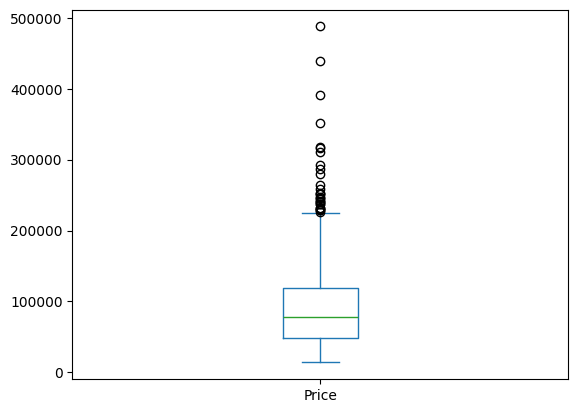

In [175]:
df['Price'].plot(kind='box')

<Axes: xlabel='Price', ylabel='Count'>

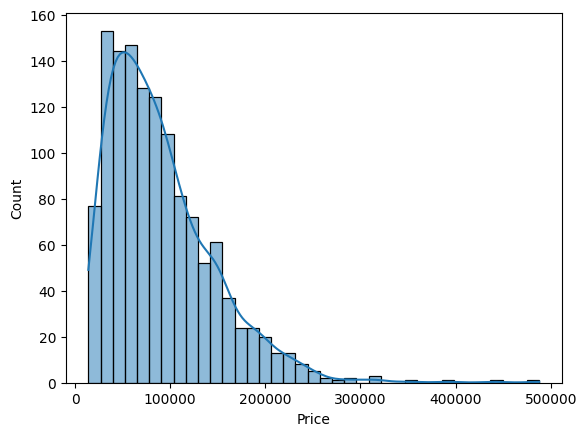

In [176]:
sns.histplot(x=df['Price'],kde=True)

<Axes: xlabel='Price', ylabel='Density'>

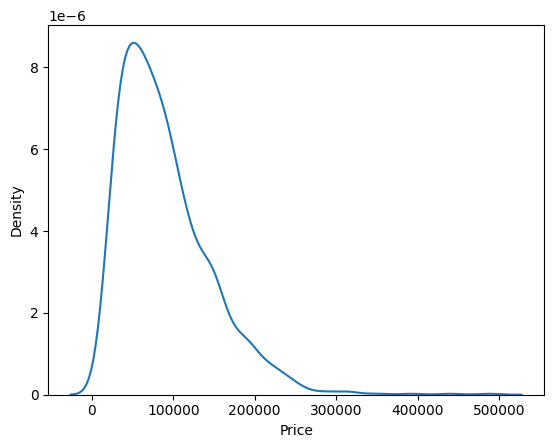

In [177]:
sns.kdeplot(x=df['Price'])

(array([ 24., 221., 221., 215., 176., 141.,  80.,  88.,  40.,  42.,  17.,
         19.,   8.,   2.,   2.,   3.,   0.,   1.,   0.,   1.,   0.,   1.,
          0.,   0.]),
 array([     0.,  20000.,  40000.,  60000.,  80000., 100000., 120000.,
        140000., 160000., 180000., 200000., 220000., 240000., 260000.,
        280000., 300000., 320000., 340000., 360000., 380000., 400000.,
        420000., 440000., 460000., 480000.]),
 <BarContainer object of 24 artists>)

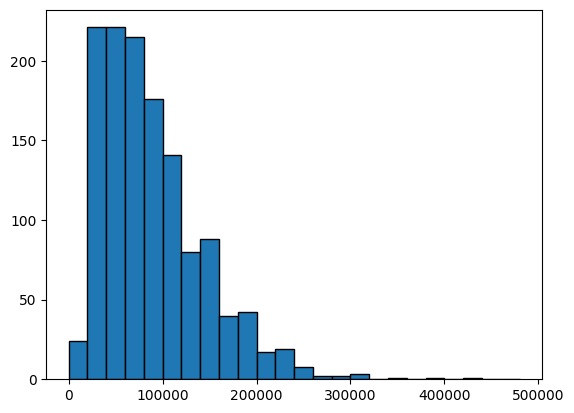

In [178]:
plt.hist(df['Price'],edgecolor='k',bins=np.arange(0,500000,20000))

In [179]:
df.duplicated().sum()

np.int64(28)

In [180]:
df[df.duplicated()]

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1275,Asus,ZenBook UX305CA-UBM1,Ultrabook,13.3,IPS Panel Full HD 1920x1080,Intel Core M 6Y30 0.9GHz,8GB,512GB SSD,Intel HD Graphics 515,Windows 10,1.2kg,58300
1276,Dell,Inspiron 3567,Notebook,15.6,1366x768,Intel Core i3 7100U 2.4GHz,6GB,1TB HDD,Intel HD Graphics 620,Windows 10,2.3kg,36700
1277,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg,23100
1278,Dell,Inspiron 3552,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,500GB HDD,Intel HD Graphics,Windows 10,2.20kg,30300
1279,Lenovo,IdeaPad Y700-15ISK,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,Nvidia GeForce GTX 960M,Windows 10,2.6kg,71900
1280,HP,Pavilion 15-AW003nv,Notebook,15.6,Full HD 1920x1080,AMD A9-Series 9410 2.9GHz,6GB,1.0TB Hybrid,AMD Radeon R7 M440,Windows 10,2.04kg,44000
1281,Dell,Inspiron 3567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R5 M430,Linux,2.3kg,64500
1282,HP,Stream 11-Y000na,Netbook,11.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,2GB,32GB Flash Storage,Intel HD Graphics 400,Windows 10,1.17kg,16700
1283,Asus,X556UJ-XO044T (i7-6500U/4GB/500GB/GeForce,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,4GB,500GB HDD,Nvidia GeForce 920M,Windows 10,2.2kg,57600
1284,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,51000


In [181]:
df.drop_duplicates(inplace=True)

In [182]:
df.duplicated().sum()

np.int64(0)

In [183]:
df.sample()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
851,Asus,Rog GL502VM-DS74,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,2.1kg,151900


In [184]:
print(df['Company'].value_counts())

Company
Dell         291
Lenovo       289
HP           268
Asus         152
Acer         101
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64


In [185]:
9+7+7+6+4+4+3+3+3+3+2

51

In [186]:
df.shape

(1275, 12)

In [187]:
51/1275

0.04

In [188]:
# we will remove laptops from the manufacturers who have manufactured less than 10 laptops(as per this data)

In [189]:
print(df.groupby('Company')['Company'].count())

Company
Acer         101
Apple         21
Asus         152
Chuwi          3
Dell         291
Fujitsu        3
Google         3
HP           268
Huawei         2
LG             3
Lenovo       289
MSI           54
Mediacom       7
Microsoft      6
Razer          7
Samsung        9
Toshiba       48
Vero           4
Xiaomi         4
Name: Company, dtype: int64


In [190]:
df = df[df.groupby('Company')['Company'].transform('count')>10]

In [191]:
df.shape

(1224, 12)

In [192]:
df

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,107200
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,71900
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,46000
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,203000
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,144300
...,...,...,...,...,...,...,...,...,...,...,...,...
1270,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,51000
1271,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,119900
1272,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,18300
1273,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,61100


In [193]:
df.reset_index(drop=True,inplace=True)

In [194]:
df

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,107200
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,71900
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,46000
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,203000
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,144300
...,...,...,...,...,...,...,...,...,...,...,...,...
1219,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,51000
1220,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,119900
1221,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,18300
1222,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,61100


In [195]:
# Univariate Analysis
print(df['Company'].value_counts())

Company
Dell       291
Lenovo     289
HP         268
Asus       152
Acer       101
MSI         54
Toshiba     48
Apple       21
Name: count, dtype: int64


<Axes: xlabel='Company'>

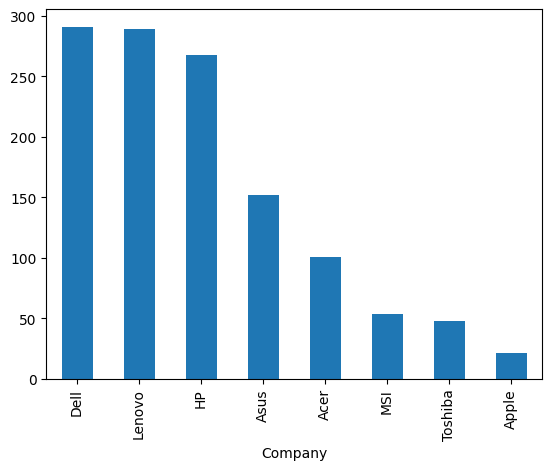

In [196]:
df['Company'].value_counts().plot(kind='bar')

<Axes: xlabel='Company', ylabel='Price'>

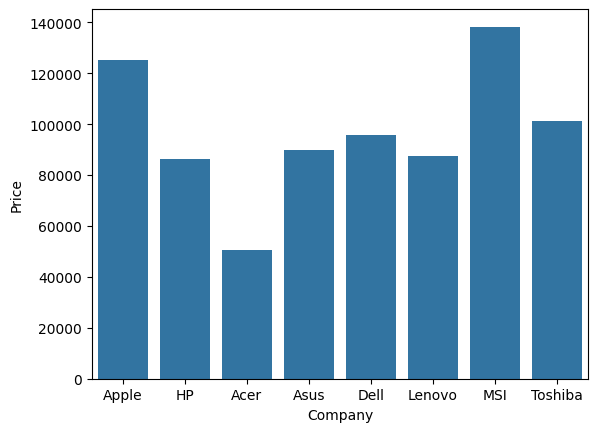

In [197]:
# Bivariate Analysis
sns.barplot(x=df['Company'],y=df['Price'],errorbar=None)

In [198]:
sorted_companies=df.groupby('Company')['Price'].mean().sort_values(ascending=False)
sorted_companies

Company
MSI        138298.148148
Apple      125128.571429
Toshiba    101418.750000
Dell        95928.522337
Asus        89894.736842
Lenovo      87497.577855
HP          86416.417910
Acer        50671.287129
Name: Price, dtype: float64

<Axes: xlabel='Company', ylabel='Price'>

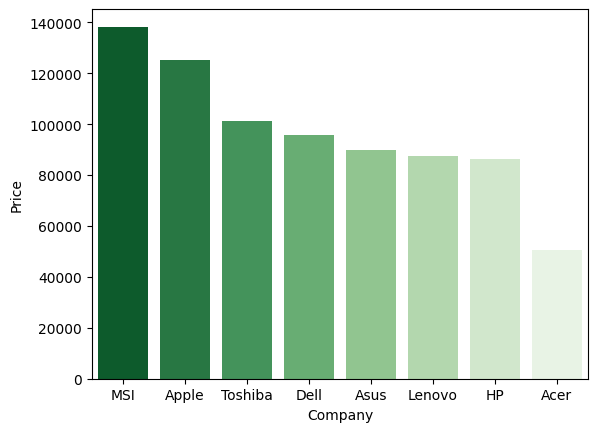

In [199]:
sns.barplot(x=df['Company'],y=df['Price'],errorbar=None,order=sorted_companies.index,
            hue=df['Company'],palette='Greens',hue_order=sorted_companies.index[::-1])

In [200]:
df.sample()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
368,Dell,Inspiron 3552,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.60GHz,4GB,500GB HDD,Intel HD Graphics 400,Windows 10,1.8kg,24700


In [201]:
print(df['Product'].value_counts())

Product
XPS 13                                       30
Inspiron 3567                                25
250 G6                                       21
Legion Y520-15IKBN                           19
Vostro 3568                                  19
                                             ..
Stream 11-Y000na                              1
X556UJ-XO044T (i7-6500U/4GB/500GB/GeForce     1
Yoga 500-14ISK                                1
15-AC110nv (i7-6500U/6GB/1TB/Radeon           1
X553SA-XX031T (N3050/4GB/500GB/W10)           1
Name: count, Length: 589, dtype: int64


In [202]:
# Max of about 25-30 categories
# if greater than that, then the analysis of that column is not very fruitful

df.drop(columns=['Product'],inplace=True)

In [203]:
df.sample()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
534,HP,Notebook,17.3,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.63kg,102400


In [204]:
print(df['TypeName'].value_counts())

TypeName
Notebook              688
Gaming                200
Ultrabook             171
2 in 1 Convertible    114
Workstation            29
Netbook                22
Name: count, dtype: int64


<Axes: xlabel='TypeName'>

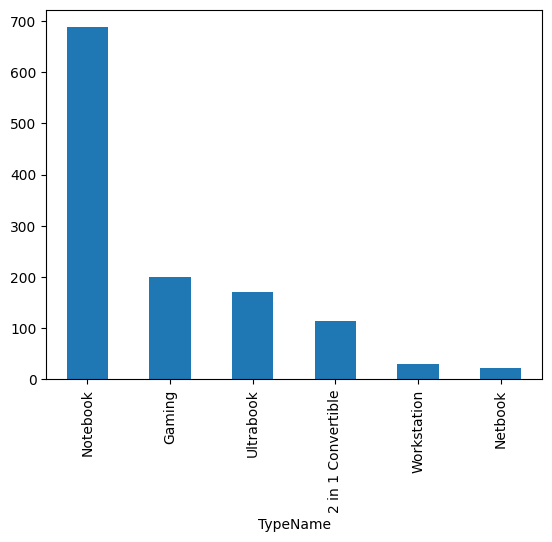

In [205]:
df['TypeName'].value_counts().plot(kind='bar')

In [206]:
sorted_types=df.groupby('TypeName')['Price'].mean().sort_values(ascending=False)
sorted_types

TypeName
Workstation           182420.689655
Gaming                133721.500000
Ultrabook             124007.017544
2 in 1 Convertible    103942.982456
Notebook               63663.953488
Netbook                55331.818182
Name: Price, dtype: float64

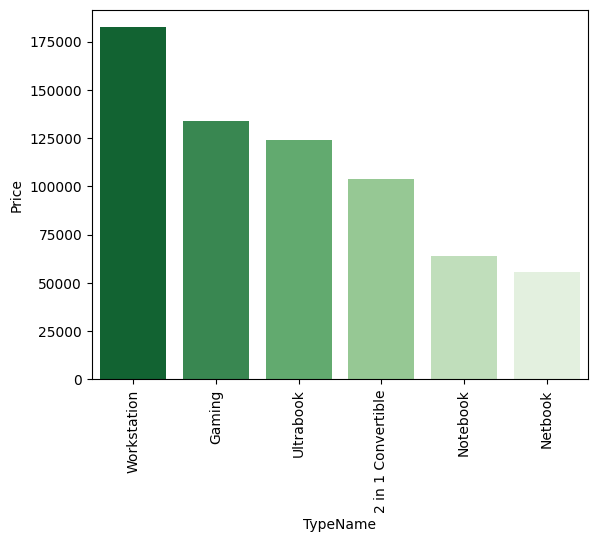

In [207]:
sns.barplot(x=df['TypeName'],y=df['Price'],errorbar=None,palette='Greens',hue=df['TypeName'],
            order=sorted_types.index,hue_order=sorted_types.index[::-1])
plt.xticks(rotation=90)
plt.show()

In [208]:
df.sample()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
202,Acer,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,1TB HDD,Nvidia GeForce GTX 1050,Linux,2.4kg,62300


In [209]:
print(df['Inches'].value_counts())

Inches
15.6    637
14.0    182
17.3    162
13.3    152
12.5     37
11.6     29
12.0      6
13.9      6
15.4      4
10.1      4
18.4      1
17.0      1
14.1      1
11.3      1
15.0      1
Name: count, dtype: int64


<Axes: xlabel='Inches', ylabel='Count'>

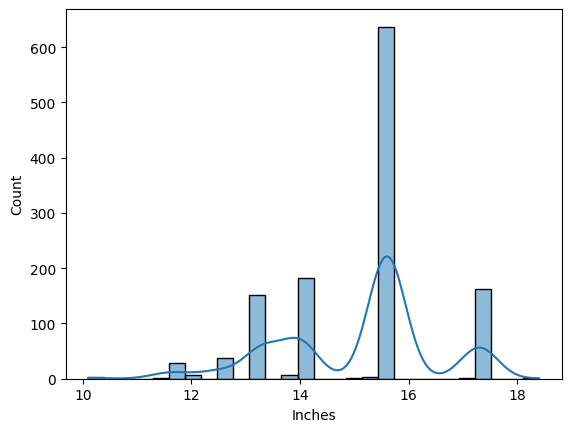

In [210]:
sns.histplot(df['Inches'],kde=True)

<Axes: xlabel='Inches', ylabel='Price'>

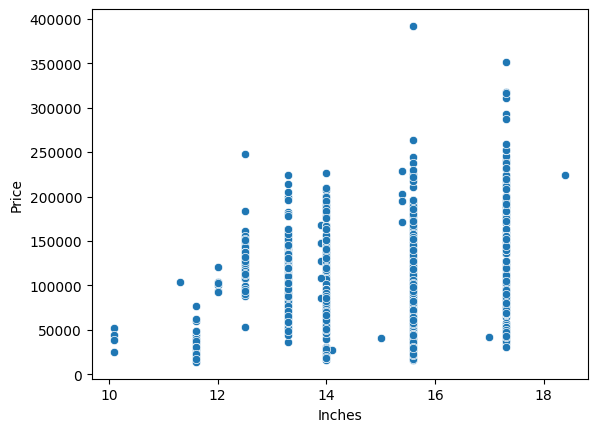

In [211]:
sns.scatterplot(x=df['Inches'],y=df['Price'])

In [212]:
df.sample()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
188,HP,Notebook,17.3,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.5kg,73100


In [213]:
print(df['ScreenResolution'].value_counts())

ScreenResolution
Full HD 1920x1080                                492
1366x768                                         258
IPS Panel Full HD 1920x1080                      217
IPS Panel Full HD / Touchscreen 1920x1080         48
Full HD / Touchscreen 1920x1080                   45
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     10
4K Ultra HD / Touchscreen 3840x2160                8
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
IPS Panel Touchscreen 2560x1440                    5
1440x900                                           4
IPS Panel Retina Display 2880

In [214]:
# X_res
# Y_res
# Touchscreen
# IPS

In [215]:
a = "IPS Panel Full HD 1920x1080"

In [216]:
a.split()

['IPS', 'Panel', 'Full', 'HD', '1920x1080']

In [217]:
a.split()[-1]

'1920x1080'

In [218]:
a.split()[-1].split('x')

['1920', '1080']

In [219]:
a.split()[-1].split('x')[1]

'1080'

In [220]:
(lambda a:a.split()[-1].split('x')[1])

<function __main__.<lambda>(a)>

In [221]:
a = "IPS Panel Full HD 1920x1080"
[1 if "IPS" in a else 0]

[1]

In [222]:
df['X_res']=df['ScreenResolution'].apply(lambda a:a.split()[-1].split('x')[0]).astype('int')
df['Y_res']=df['ScreenResolution'].apply(lambda a:a.split()[-1].split('x')[1]).astype('int')

In [223]:
df['IPS']=df['ScreenResolution'].apply(lambda a:1 if "IPS" in a else 0)
df['Touchscreen']=df['ScreenResolution'].apply(lambda a:1 if "Touchscreen" in a else 0)

In [224]:
df.sample(10)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_res,Y_res,IPS,Touchscreen
348,Dell,Gaming,15.6,Full HD 1920x1080,Intel Core i5 7300HQ 2.5GHz,8GB,1TB HDD,Nvidia GeForce GTX 1050,Windows 10,2.65kg,79900,1920,1080,0,0
1124,Lenovo,Notebook,15.6,1366x768,Intel Core i5 6200U 2.3GHz,4GB,500GB HDD,Intel HD Graphics 520,No OS,2.1kg,31800,1366,768,0,0
606,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,4GB,1TB HDD,Nvidia GeForce 920MX,Windows 10,2.2kg,46300,1920,1080,0,0
241,Dell,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 8550U 1.8GHz,8GB,1TB HDD,Intel UHD Graphics 620,Windows 10,2.08kg,65500,1920,1080,1,1
996,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,2.3kg,84000,1920,1080,0,0
739,HP,Ultrabook,12.5,1366x768,Intel Core i5 6200U 2.3GHz,4GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.26kg,99500,1366,768,0,0
7,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,92700,1440,900,0,0
169,Toshiba,Notebook,15.6,1366x768,Intel Core i3 7100U 2.4GHz,4GB,500GB HDD,Intel HD Graphics 620,Windows 10,2kg,39100,1366,768,0,0
1180,Lenovo,Netbook,12.5,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.50GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,132000,1920,1080,1,1
1208,MSI,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,128GB SSD + 1TB HDD,Nvidia GeForce GTX 960M,Windows 10,2.4kg,98300,1920,1080,0,0


In [225]:
df.drop(columns=['ScreenResolution'],inplace=True)

In [226]:
df.sample(2)

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_res,Y_res,IPS,Touchscreen
1086,Lenovo,Notebook,15.6,Intel Core i7 6500U 2.5GHz,16GB,1.0TB Hybrid,AMD Radeon R7 M360,Windows 10,2.5kg,87900,1920,1080,0,0
158,Acer,Notebook,17.3,Intel Core i5 8250U 1.6GHz,4GB,256GB SSD,Nvidia GeForce MX150,Windows 10,3kg,64400,1920,1080,1,0


In [227]:
df['IPS'].value_counts()

IPS
0    885
1    339
Name: count, dtype: int64

<Axes: xlabel='IPS'>

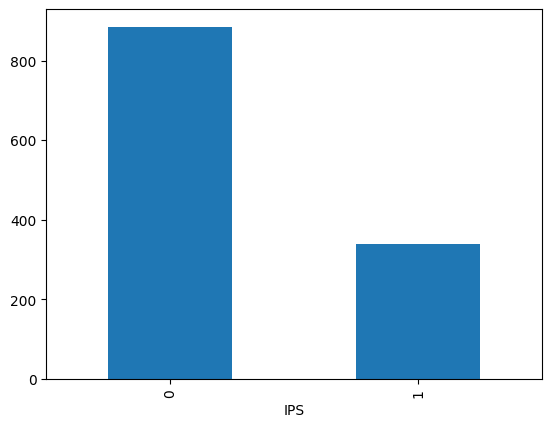

In [228]:
df['IPS'].value_counts().plot(kind='bar')

<Axes: xlabel='IPS', ylabel='Price'>

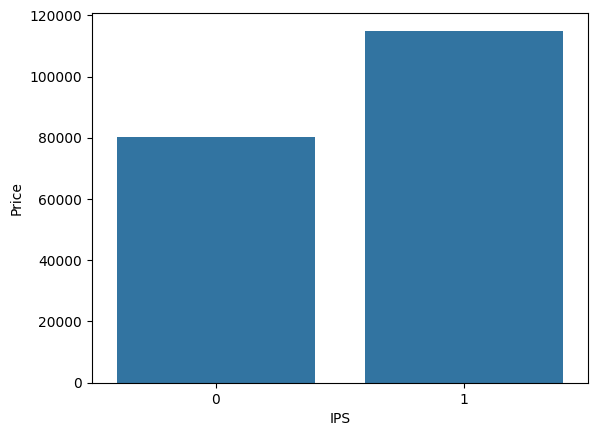

In [229]:
sns.barplot(x=df['IPS'],y=df['Price'],errorbar=None)

In [230]:
df['Touchscreen'].value_counts()

Touchscreen
0    1055
1     169
Name: count, dtype: int64

<Axes: xlabel='Touchscreen'>

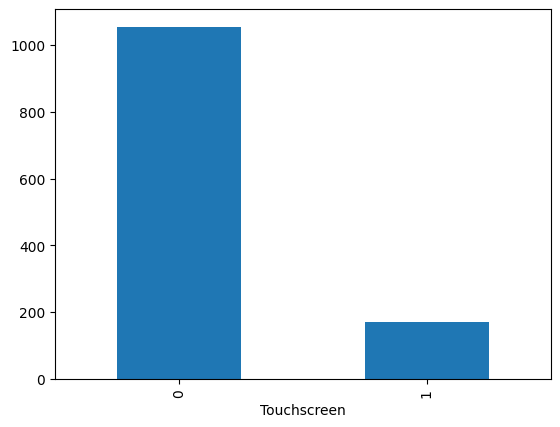

In [231]:
df['Touchscreen'].value_counts().plot(kind='bar')

<Axes: xlabel='Touchscreen', ylabel='Price'>

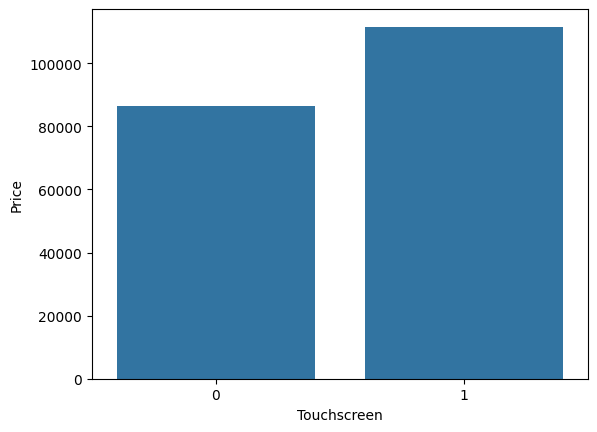

In [232]:
sns.barplot(x=df['Touchscreen'],y=df['Price'],errorbar=None)

In [233]:
df.sample(4)

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_res,Y_res,IPS,Touchscreen
734,Dell,Gaming,15.6,Intel Core i7 6700HQ 2.6GHz,16GB,128GB SSD + 1TB HDD,Nvidia GeForce GTX 960M,Windows 10,2.72kg,87900,3840,2160,1,1
1046,Dell,Ultrabook,13.3,Intel Core i5 8250U 1.6GHz,4GB,256GB SSD,AMD Radeon 530,Windows 10,1.4kg,65500,1920,1080,1,0
765,Dell,Ultrabook,13.3,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.29kg,119900,1920,1080,0,0
693,MSI,Gaming,17.3,Intel Core i7 7700HQ 2.8GHz,8GB,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050 Ti,Windows 10,2.7kg,107900,1920,1080,0,0


In [234]:
df['Ram']=df['Ram'].str.replace("GB","").astype('int')
df['Weight']=df['Weight'].str.replace("kg","").astype('float')

In [235]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1224 non-null   str    
 1   TypeName     1224 non-null   str    
 2   Inches       1224 non-null   float64
 3   Cpu          1224 non-null   str    
 4   Ram          1224 non-null   int64  
 5   Memory       1224 non-null   str    
 6   Gpu          1224 non-null   str    
 7   OpSys        1224 non-null   str    
 8   Weight       1224 non-null   float64
 9   Price        1224 non-null   int64  
 10  X_res        1224 non-null   int64  
 11  Y_res        1224 non-null   int64  
 12  IPS          1224 non-null   int64  
 13  Touchscreen  1224 non-null   int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 231.4 KB


In [236]:
df.sample(4)

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_res,Y_res,IPS,Touchscreen
1136,Asus,Gaming,15.6,Intel Core i7 6700HQ 2.6GHz,8,256GB SSD + 1TB HDD,Nvidia GeForce GTX 960M,Windows 10,2.591,72700,1920,1080,1,0
878,Toshiba,Notebook,15.6,Intel Core i7 6600U 2.6GHz,16,256GB SSD,Nvidia GeForce 930M,Windows 10,2.400,158000,1920,1080,1,0
429,Lenovo,Ultrabook,12.5,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.360,114300,1920,1080,1,0
1064,Dell,Notebook,15.6,Intel Core i5 6200U 2.3GHz,4,500GB HDD,AMD Radeon R5 M315,Windows 7,2.240,61500,1366,768,0,0


In [237]:
df['Ram'].value_counts()

Ram
8     595
4     351
16    186
6      34
12     25
32     15
2      14
24      3
64      1
Name: count, dtype: int64

<Axes: xlabel='Ram'>

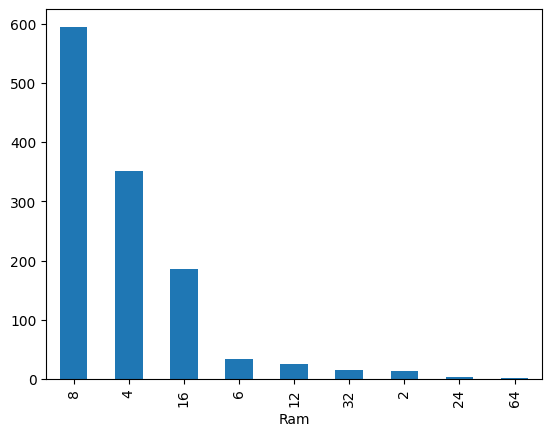

In [238]:
df['Ram'].value_counts().plot(kind='bar')

<Axes: xlabel='Ram', ylabel='Price'>

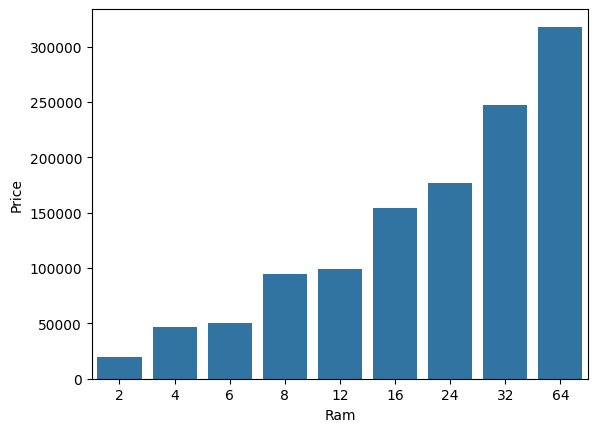

In [239]:
sns.barplot(x=df['Ram'],y=df['Price'],errorbar=None)

In [240]:
df.corr(numeric_only=True)

,Inches,Ram,Weight,Price,X_res,Y_res,IPS,Touchscreen
Inches,1.000000,0.239155,0.824959,0.055327,-0.057739,-0.071772,-0.104090,-0.359497
Ram,0.239155,1.000000,0.394187,0.726618,0.415731,0.412278,0.223322,0.094037
Weight,0.824959,0.394187,1.000000,0.212029,-0.025155,-0.036765,0.038753,-0.291506
Price,0.055327,0.726618,0.212029,1.000000,0.553697,0.552954,0.289224,0.161421
X_res,-0.057739,0.415731,-0.025155,0.553697,1.000000,0.997454,0.283969,0.320954
Y_res,-0.071772,0.412278,-0.036765,0.552954,0.997454,1.000000,0.294360,0.317174
IPS,-0.104090,0.223322,0.038753,0.289224,0.283969,0.294360,1.000000,0.154500
Touchscreen,-0.359497,0.094037,-0.291506,0.161421,0.320954,0.317174,0.154500,1.000000


In [241]:
df.corr(numeric_only=True)['Price']

Inches         0.055327
Ram            0.726618
Weight         0.212029
Price          1.000000
X_res          0.553697
Y_res          0.552954
IPS            0.289224
Touchscreen    0.161421
Name: Price, dtype: float64

In [242]:
# pixel density
df['ppi']=round((df["X_res"]**2+df["Y_res"]**2)**0.5/df['Inches'],2)

In [243]:
df.sample(3)

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_res,Y_res,IPS,Touchscreen,ppi
474,Asus,Gaming,15.6,Intel Core i7 7700HQ 2.8GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,1.99,108000,1920,1080,0,0,141.21
86,Asus,Gaming,15.6,Intel Core i7 7700HQ 2.8GHz,16,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,2.20,115900,1920,1080,1,0,141.21
132,HP,Notebook,14.0,Intel Core i7 8550U 1.8GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,1.63,79000,1920,1080,0,0,157.35


In [244]:
df.corr(numeric_only=True)['Price']

Inches         0.055327
Ram            0.726618
Weight         0.212029
Price          1.000000
X_res          0.553697
Y_res          0.552954
IPS            0.289224
Touchscreen    0.161421
ppi            0.483778
Name: Price, dtype: float64

In [245]:
df.drop(columns=['X_res','Y_res','Inches'],inplace=True)

In [246]:
df.sample(4)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,Touchscreen,ppi
1051,HP,Notebook,Intel Pentium Quad Core N3710 1.6GHz,4,1TB HDD,Intel HD Graphics 405,Windows 10,1.96,40000,0,0,100.45
1041,HP,Notebook,Intel Pentium Dual Core 4405Y 1.5GHz,4,32GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.29,49200,0,0,276.05
82,Acer,Notebook,AMD A9-Series 9420 3GHz,4,1TB HDD,AMD Radeon R5,Windows 10,2.10,31600,0,0,100.45
1089,MSI,Gaming,Intel Core i7 6820HQ 2.7GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 980M,Windows 10,3.78,191900,0,0,127.34


<Axes: xlabel='ppi', ylabel='Count'>

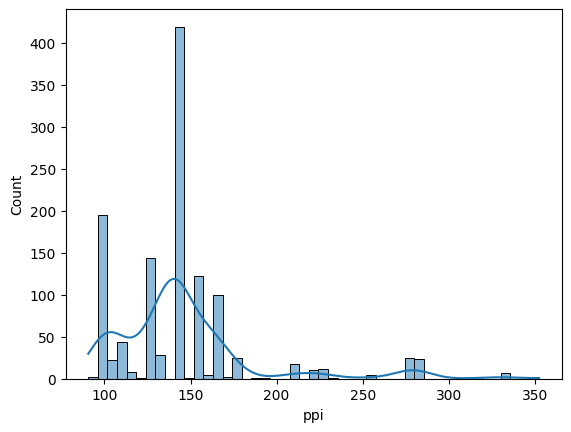

In [247]:
sns.histplot(df['ppi'],kde=True)

In [248]:
df['ppi'].value_counts()

ppi
141.21    419
100.45    195
127.34    131
157.35    122
165.63    100
111.94     42
135.09     28
276.05     25
176.23     25
282.42     23
106.11     22
209.80     18
125.37      9
117.83      8
331.26      7
226.98      6
226.42      6
254.67      5
127.68      4
220.53      4
224.17      4
158.48      4
90.58       2
352.47      2
316.97      2
169.78      2
220.84      2
119.72      1
189.91      1
107.99      1
111.14      1
194.95      1
234.98      1
146.86      1
Name: count, dtype: int64

<Axes: xlabel='ppi', ylabel='Price'>

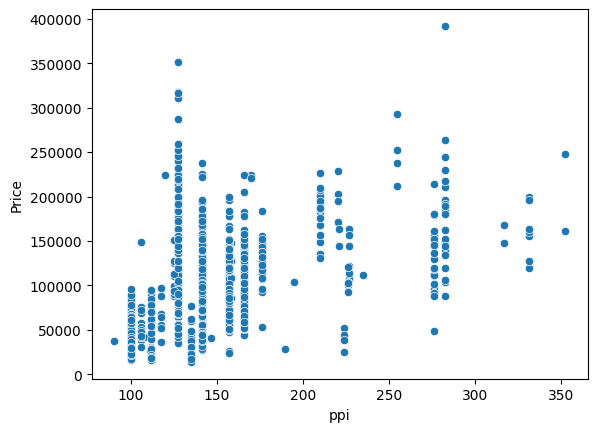

In [249]:
sns.scatterplot(x=df['ppi'],y=df['Price'])

In [250]:
df['Cpu'].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz              183
Intel Core i7 7700HQ 2.8GHz             142
Intel Core i7 7500U 2.7GHz              124
Intel Core i7 8550U 1.8GHz               71
Intel Core i5 8250U 1.6GHz               71
                                       ... 
Intel Pentium Dual Core 4405Y 1.5GHz      1
Intel Core M 6Y54 1.1GHz                  1
AMD E-Series 9000 2.2GHz                  1
Intel Core M 6Y30 0.9GHz                  1
AMD A9-Series 9410 2.9GHz                 1
Name: count, Length: 111, dtype: int64

In [251]:
df['Cpu_Speed']=df['Cpu'].str.split().str[-1].str.replace("GHz","").astype('float')

In [252]:
df.sample(4)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,Touchscreen,ppi,Cpu_Speed
313,Asus,Notebook,Intel Core i7 7500U 2.7GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,2.00,87500,0,0,157.35,2.7
826,Toshiba,Ultrabook,Intel Core i5 6200U 2.3GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,1.20,87600,0,0,117.83,2.3
1157,Lenovo,Notebook,AMD E-Series 9000 2.2GHz,4,500GB HDD,AMD Radeon R2 Graphics,Windows 10,2.20,23900,0,0,100.45,2.2
132,HP,Notebook,Intel Core i7 8550U 1.8GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,1.63,79000,0,0,157.35,1.8


<Axes: xlabel='Cpu_Speed', ylabel='Count'>

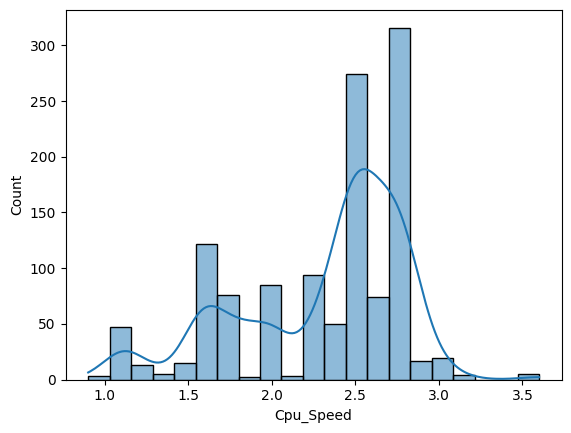

In [253]:
sns.histplot(df['Cpu_Speed'],kde=True)

In [254]:
df['Cpu']=df['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))

In [255]:
print(df['Cpu'].value_counts())

Cpu
Intel Core i7               493
Intel Core i5               411
Intel Core i3               134
Intel Celeron Dual           66
Intel Pentium Quad           27
Intel Core M                 16
AMD A9-Series 9420           12
AMD A6-Series 9220            8
AMD A12-Series 9720P          7
Intel Celeron Quad            5
Intel Atom x5-Z8550           4
AMD A8-Series 7410            4
AMD Ryzen 1700                3
Intel Pentium Dual            3
AMD E-Series E2-9000e         2
Intel Xeon E3-1505M           2
AMD A10-Series A10-9620P      2
AMD A6-Series A6-9220         2
AMD A10-Series 9600P          2
AMD A10-Series 9620P          2
AMD E-Series 7110             2
AMD A9-Series A9-9420         2
Intel Xeon E3-1535M           2
Intel Atom x5-Z8350           1
AMD E-Series E2-6110          1
AMD FX 9830P                  1
AMD E-Series 6110             1
AMD E-Series 9000e            1
AMD Ryzen 1600                1
AMD E-Series E2-9000          1
AMD A6-Series 7310            1
AMD 

In [256]:
def fetch_processor_names(text):
    if text.split()[1] == 'Core':
        return text
    elif text.split()[0] == 'Intel':
        return " ".join(text.split()[0:2])
    else:
        return "AMD "+text[4]+"-Series"

In [257]:
df['Cpu']=df['Cpu'].apply(fetch_processor_names)

In [258]:
print(df['Cpu'].value_counts())

Cpu
Intel Core i7    493
Intel Core i5    411
Intel Core i3    134
Intel Celeron     71
AMD A-Series      45
Intel Pentium     30
Intel Core M      16
AMD E-Series       9
Intel Atom         5
AMD R-Series       4
Intel Xeon         4
AMD F-Series       2
Name: count, dtype: int64


<Axes: xlabel='Cpu'>

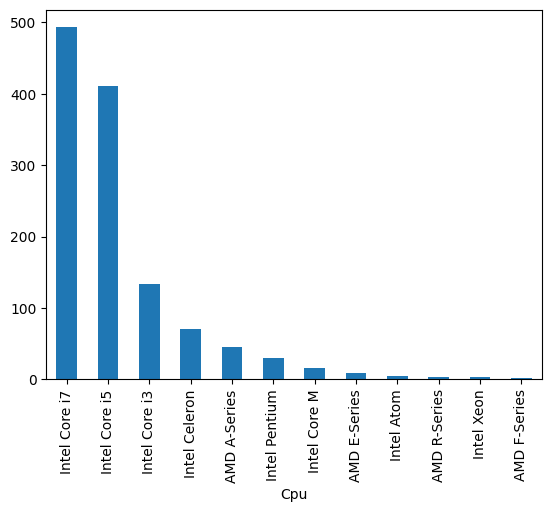

In [259]:
df['Cpu'].value_counts().plot(kind='bar')

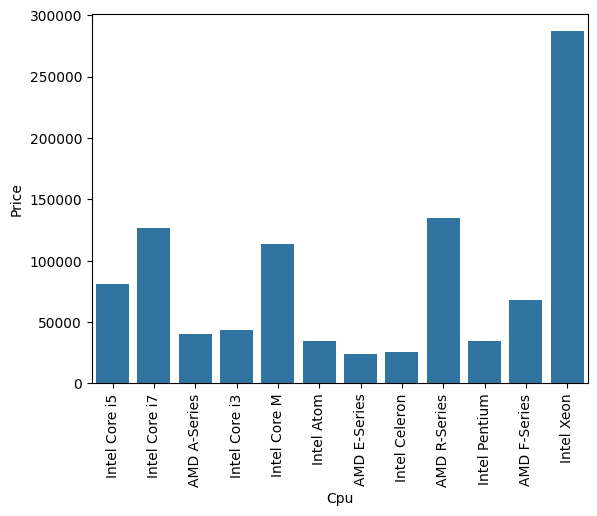

In [260]:
sns.barplot(x=df['Cpu'],y=df['Price'],errorbar=None)
plt.xticks(rotation=90)
plt.show()

In [261]:
sorted_cpus=df.groupby('Cpu')['Price'].mean().sort_values(ascending=False)
sorted_cpus

Cpu
Intel Xeon       286700.000000
AMD R-Series     134825.000000
Intel Core i7    126391.277890
Intel Core M     113550.000000
Intel Core i5     80949.635036
AMD F-Series      67900.000000
Intel Core i3     43420.895522
AMD A-Series      40008.888889
Intel Atom        34960.000000
Intel Pentium     34833.333333
Intel Celeron     25807.042254
AMD E-Series      24055.555556
Name: Price, dtype: float64

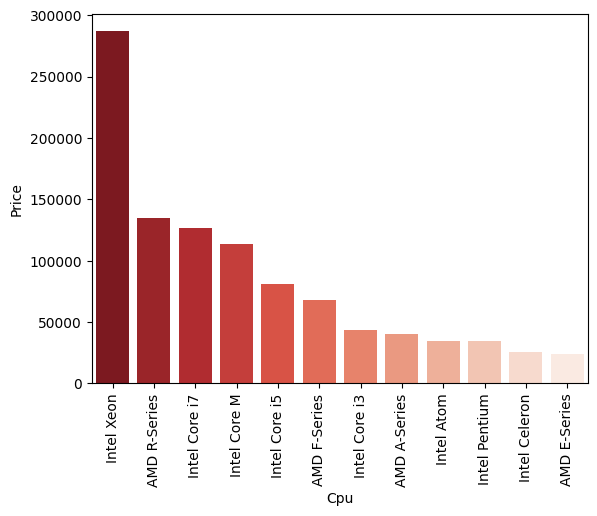

In [262]:
sns.barplot(x=df['Cpu'],y=df['Price'],errorbar=None,order=sorted_cpus.index,
            palette='Reds',hue=df['Cpu'],hue_order=sorted_cpus.index[::-1])
plt.xticks(rotation=90)
plt.show()

In [263]:
df.sample()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,Touchscreen,ppi,Cpu_Speed
886,HP,Ultrabook,Intel Core i5,4,500GB HDD,Intel HD Graphics 520,Windows 10,1.26,126300,0,0,176.23,2.3


In [264]:
df['OpSys'].value_counts()

OpSys
Windows 10      1011
No OS             63
Linux             58
Windows 7         45
Chrome OS         22
macOS             13
Mac OS X           8
Android            2
Windows 10 S       2
Name: count, dtype: int64

In [265]:
def fetch_os_name(text):
    if text=="Windows 10" or text=="Windows 10 S":
        return "Windows 10"
    elif text == "macOS" or text == "Mac OS X":
        return "MacOS"
    elif text == "Windows 7" or text == "No OS":
        return text
    else:
        return "Linux/Chrome OS/Android"

In [266]:
df['OpSys']=df['OpSys'].apply(fetch_os_name)

In [267]:
df['OpSys'].value_counts()

OpSys
Windows 10                 1013
Linux/Chrome OS/Android      82
No OS                        63
Windows 7                    45
MacOS                        21
Name: count, dtype: int64

<Axes: xlabel='OpSys'>

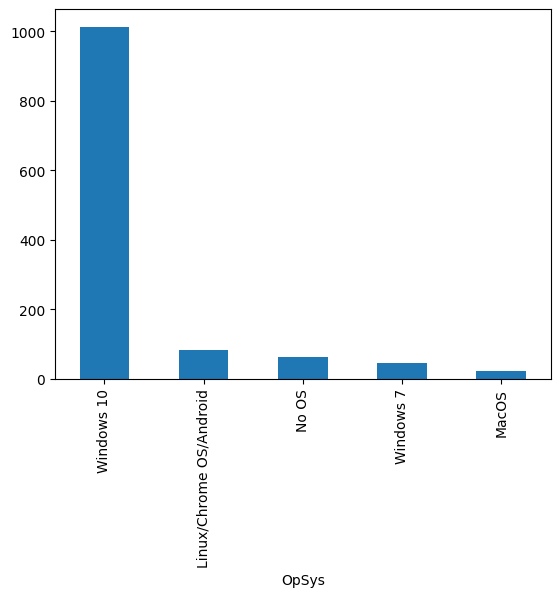

In [268]:
df['OpSys'].value_counts().plot(kind='bar')

In [269]:
sorted_os = df.groupby('OpSys')['Price'].mean().sort_values(ascending=False)
sorted_os

OpSys
Windows 7                  134928.888889
MacOS                      125128.571429
Windows 10                  93700.888450
Linux/Chrome OS/Android     44793.902439
No OS                       44693.650794
Name: Price, dtype: float64

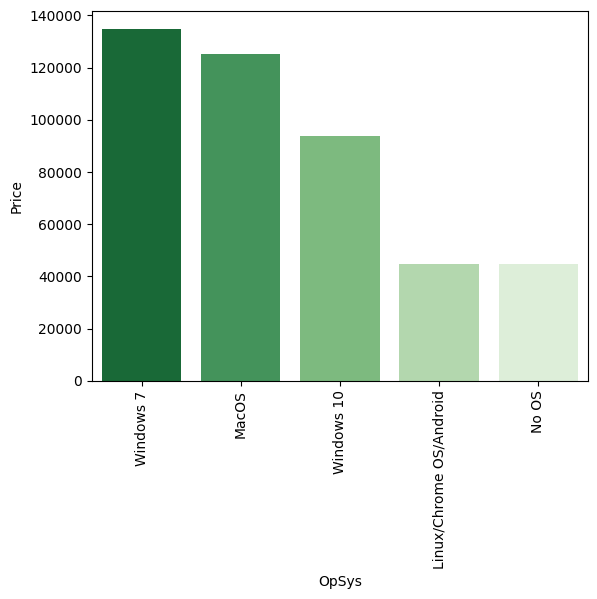

In [270]:
sns.barplot(x=df['OpSys'],y=df['Price'],errorbar=None,hue=df['OpSys'],palette='Greens',
            order=sorted_os.index,hue_order=sorted_os.index[::-1])
plt.xticks(rotation=90)
plt.show()

In [271]:
df.sample()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,Touchscreen,ppi,Cpu_Speed
674,Lenovo,Notebook,Intel Core i3,4,500GB HDD,Intel HD Graphics 520,No OS,1.9,36000,0,0,100.45,2.0


In [272]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      265
Intel HD Graphics 520      179
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     65
Nvidia GeForce GTX 1060     45
                          ... 
AMD Radeon R5 M315           1
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
Name: count, Length: 108, dtype: int64

In [273]:
df['Gpu']=df['Gpu'].apply(lambda x:" ".join(x.split()[0:2]))

In [274]:
df['Gpu'].value_counts()

Gpu
Intel HD          586
Nvidia GeForce    353
AMD Radeon        166
Intel UHD          68
Nvidia Quadro      31
Intel Iris         11
AMD FirePro         5
AMD R4              1
Nvidia GTX          1
AMD R17M-M1-70      1
Intel Graphics      1
Name: count, dtype: int64

In [275]:
def fetch_gpu(text):
    if text=="Nvidia GTX":
        return "Nvidia GeForce"
    elif text=="Intel Graphics":
        return "Intel HD"
    elif text.split()[0]=="AMD":
        return "AMD GPU"
    else:
        return text

In [276]:
df['Gpu']=df['Gpu'].apply(fetch_gpu)

In [277]:
df['Gpu'].value_counts()

Gpu
Intel HD          587
Nvidia GeForce    354
AMD GPU           173
Intel UHD          68
Nvidia Quadro      31
Intel Iris         11
Name: count, dtype: int64

<Axes: xlabel='Gpu'>

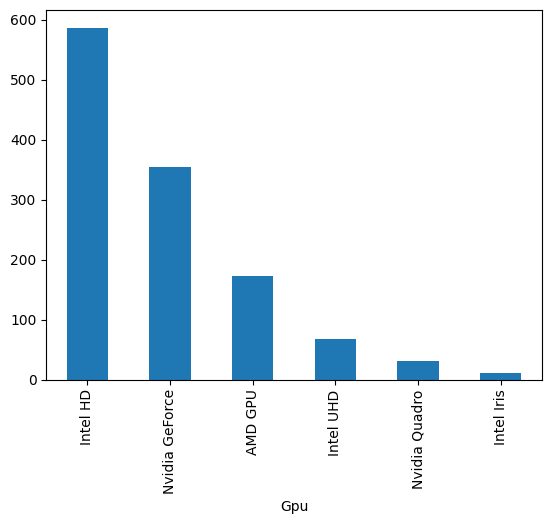

In [278]:
df['Gpu'].value_counts().plot(kind='bar')

In [279]:
sorted_gpu = df.groupby('Gpu')['Price'].mean().sort_values(ascending=False)
sorted_gpu

Gpu
Nvidia Quadro     196670.967742
Intel Iris        138300.000000
Nvidia GeForce    110230.790960
Intel UHD          96448.529412
Intel HD           78747.018739
AMD GPU            61760.115607
Name: Price, dtype: float64

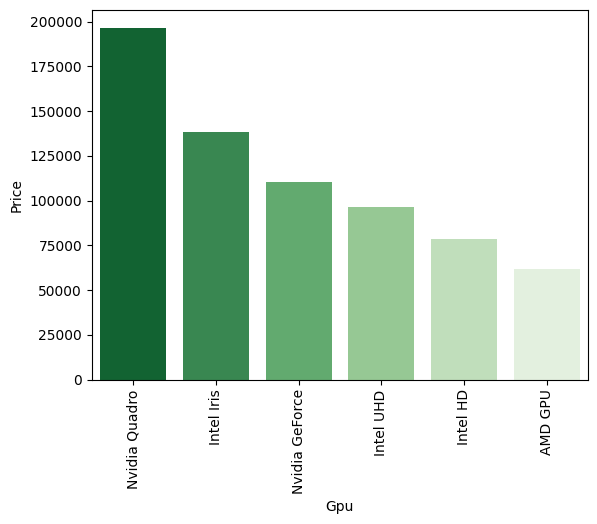

In [280]:
sns.barplot(x=df['Gpu'],y=df['Price'],errorbar=None,hue=df['Gpu'],palette='Greens',
            order=sorted_gpu.index,hue_order=sorted_gpu.index[::-1])
plt.xticks(rotation=90)
plt.show()

In [281]:
df.sample()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,Touchscreen,ppi,Cpu_Speed
808,HP,2 in 1 Convertible,Intel Core i5,8,256GB SSD,Intel HD,Windows 10,1.28,182200,0,1,165.63,2.5


In [282]:
print(df['Memory'].value_counts())

Memory
256GB SSD                        393
1TB HDD                          214
500GB HDD                        124
512GB SSD                        105
128GB SSD +  1TB HDD              93
256GB SSD +  1TB HDD              73
128GB SSD                         71
32GB Flash Storage                29
2TB HDD                           16
512GB SSD +  1TB HDD              14
1TB SSD                           12
64GB Flash Storage                10
256GB SSD +  2TB HDD              10
256GB Flash Storage                8
1.0TB Hybrid                       7
16GB Flash Storage                 6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
256GB SSD +  256GB SSD             2
32GB SSD                           2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
1TB SSD +  1TB HDD                 2
512GB Flash Storage                2
64GB SSD                       

In [283]:
# SSD
# HDD
# Hybrid
# Flash
# SSD+HDD
# SSD+SSD
# Flash + HDD
# HDD + HDD
# SSD + Hybrid

In [284]:
df['Memory']=df['Memory'].astype('str').replace(r"\.0","",regex=True)

In [285]:
print(df['Memory'].value_counts())

Memory
256GB SSD                        393
1TB HDD                          215
500GB HDD                        124
512GB SSD                        105
128GB SSD +  1TB HDD              93
256GB SSD +  1TB HDD              73
128GB SSD                         71
32GB Flash Storage                29
2TB HDD                           16
512GB SSD +  1TB HDD              14
1TB SSD                           12
64GB Flash Storage                10
256GB SSD +  2TB HDD              10
256GB Flash Storage                8
1TB Hybrid                         7
16GB Flash Storage                 6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
256GB SSD +  256GB SSD             2
32GB SSD                           2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
1TB SSD +  1TB HDD                 2
512GB Flash Storage                2
64GB SSD                       

In [286]:
df['Memory']=df['Memory'].str.replace("GB","")
df['Memory']=df['Memory'].str.replace("TB","000")

In [287]:
print(df['Memory'].value_counts())

Memory
256 SSD                         393
1000 HDD                        215
500 HDD                         124
512 SSD                         105
128 SSD +  1000 HDD              93
256 SSD +  1000 HDD              73
128 SSD                          71
32 Flash Storage                 29
2000 HDD                         16
512 SSD +  1000 HDD              14
1000 SSD                         12
64 Flash Storage                 10
256 SSD +  2000 HDD              10
256 Flash Storage                 8
1000 Hybrid                       7
16 Flash Storage                  6
180 SSD                           5
128 Flash Storage                 4
16 SSD                            3
512 SSD +  2000 HDD               3
256 SSD +  256 SSD                2
32 SSD                            2
256 SSD +  500 HDD                2
128 SSD +  2000 HDD               2
1000 SSD +  1000 HDD              2
512 Flash Storage                 2
64 SSD                            1
512 SSD +  512 SSD   

In [288]:
new=df['Memory'].str.split('+',expand=True)

In [289]:
df['first']=new[0]
df['first']=df['first'].str.strip()
df['second']=new[1]

In [290]:
# df['Memory'].head(30)

In [291]:
# df['Memory'].str.split('+').head(30)

In [292]:
# df['Memory'].str.split('+',expand=True).head(30)

In [293]:
df['Layer1SSD']=df['first'].apply(lambda x:1 if "SSD" in x else 0)
df['Layer1HDD']=df['first'].apply(lambda x:1 if "HDD" in x else 0)
df['Layer1Hybrid']=df['first'].apply(lambda x:1 if "Hybrid" in x else 0)
df['Layer1Flash']=df['first'].apply(lambda x:1 if "Flash" in x else 0)

In [294]:
df['first']=df['first'].str.replace(r"\D","",regex=True)
# \D : anything which is not a digit
# \d : anything which is a digit

In [295]:
df.sample(15)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,Touchscreen,ppi,Cpu_Speed,first,second,Layer1SSD,Layer1HDD,Layer1Hybrid,Layer1Flash
1054,Dell,Ultrabook,Intel Core i3,4,128 SSD,Intel HD,Windows 7,1.50,93400,0,0,125.37,2.3,128,NaN,1,0,0,0
41,Asus,Notebook,Intel Core i5,8,1000 HDD,Nvidia GeForce,Linux/Chrome OS/Android,2.30,41800,0,0,100.45,2.5,1000,NaN,0,1,0,0
749,MSI,Gaming,Intel Core i7,16,256 SSD + 1000 HDD,Nvidia GeForce,Windows 10,1.60,151300,1,0,157.35,2.8,256,1000 HDD,1,0,0,0
192,Dell,Gaming,Intel Core i7,16,512 SSD + 1000 HDD,Nvidia GeForce,Windows 10,2.65,147600,1,0,282.42,2.8,512,1000 HDD,1,0,0,0
1153,Dell,Ultrabook,Intel Core i7,16,512 SSD,Intel HD,Windows 10,1.20,214400,0,1,276.05,2.7,512,NaN,1,0,0,0
641,Acer,Notebook,Intel Core i3,4,128 SSD,Intel HD,Linux/Chrome OS/Android,2.10,33000,0,0,100.45,2.0,128,NaN,1,0,0,0
76,Acer,Notebook,Intel Core i3,4,1000 HDD,Nvidia GeForce,Windows 10,2.20,42400,0,0,141.21,2.7,1000,NaN,0,1,0,0
730,Asus,Ultrabook,Intel Core i5,8,256 SSD,Intel HD,Windows 10,1.20,90300,1,0,276.05,2.5,256,NaN,1,0,0,0
376,Lenovo,Ultrabook,Intel Core i7,8,512 SSD,Intel HD,Windows 10,1.13,182600,1,0,209.80,2.7,512,NaN,1,0,0,0
622,Asus,Gaming,Intel Core i7,32,512 SSD,Nvidia GeForce,Windows 10,3.80,223900,1,0,127.34,2.7,512,NaN,1,0,0,0


In [296]:
df['second']=df['second'].fillna("0")

In [297]:
# df['second'].fillna("0",inplace=True)
# df.fillna({'second':0},inplace=True)
df['second'] = df['second'].str.strip()

In [298]:
df.sample(15)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,Touchscreen,ppi,Cpu_Speed,first,second,Layer1SSD,Layer1HDD,Layer1Hybrid,Layer1Flash
1144,Dell,2 in 1 Convertible,Intel Core i5,8,256 SSD,Intel HD,Windows 10,1.60,95900,1,1,165.63,2.5,256,0,1,0,0,0
807,Asus,Ultrabook,Intel Core i5,8,512 SSD,Nvidia GeForce,Windows 10,1.45,82100,1,0,165.63,2.3,512,0,1,0,0,0
514,Asus,Gaming,Intel Core i5,8,128 SSD + 1000 HDD,Nvidia GeForce,Windows 10,2.30,131900,1,0,141.21,2.5,128,1000 HDD,1,0,0,0
1202,Lenovo,Notebook,Intel Core i5,8,256 SSD,Intel HD,Windows 10,1.90,85800,1,0,157.35,2.3,256,0,1,0,0,0
229,Asus,Gaming,Intel Core i7,32,512 SSD + 1000 HDD,Nvidia GeForce,Windows 10,4.70,311200,0,0,127.34,2.9,512,1000 HDD,1,0,0,0
820,Lenovo,Notebook,Intel Core i5,8,1000 HDD,Intel HD,Windows 10,2.30,68100,1,0,141.21,2.5,1000,0,0,1,0,0
680,Lenovo,Gaming,Intel Core i7,8,128 SSD + 1000 HDD,Nvidia GeForce,Windows 10,2.50,99900,1,0,141.21,2.8,128,1000 HDD,1,0,0,0
689,Lenovo,Ultrabook,Intel Core i7,8,512 SSD,Intel HD,Windows 10,1.17,134900,1,0,209.80,2.5,512,0,1,0,0,0
422,Lenovo,Notebook,Intel Core i7,16,512 SSD,Nvidia Quadro,Windows 10,2.50,195900,0,0,141.21,2.9,512,0,1,0,0,0
639,HP,Notebook,Intel Core i7,8,1000 HDD,AMD GPU,Windows 10,2.10,59600,0,0,141.21,2.7,1000,0,0,1,0,0


In [299]:
df['Layer2SSD']=df['second'].apply(lambda x:1 if "SSD" in x else 0)
df['Layer2HDD']=df['second'].apply(lambda x:1 if "HDD" in x else 0)
df['Layer2Hybrid']=df['second'].apply(lambda x:1 if "Hybrid" in x else 0)
df['Layer2Flash']=df['second'].apply(lambda x:1 if "Flash" in x else 0)

In [300]:
df['second']=df['second'].str.replace(r"\D","",regex=True)

In [301]:
df.sample(15)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,...,first,second,Layer1SSD,Layer1HDD,Layer1Hybrid,Layer1Flash,Layer2SSD,Layer2HDD,Layer2Hybrid,Layer2Flash
661,Lenovo,Notebook,Intel Core i5,4,256 SSD,Intel HD,Windows 10,1.70,55900,0,...,256,0,1,0,0,0,0,0,0,0
829,Dell,Workstation,Intel Core i7,8,1000 HDD,Nvidia Quadro,Windows 10,2.23,142200,0,...,1000,0,0,1,0,0,0,0,0,0
162,MSI,Gaming,Intel Core i7,16,256 SSD + 1000 HDD,Nvidia GeForce,Windows 10,2.40,143900,1,...,256,1000,1,0,0,0,0,1,0,0
340,Dell,Ultrabook,Intel Core i5,8,1000 HDD,AMD GPU,Windows 10,1.90,53000,0,...,1000,0,0,1,0,0,0,0,0,0
976,HP,Notebook,Intel Core i5,8,256 SSD,Intel HD,Windows 10,1.11,91900,1,...,256,0,1,0,0,0,0,0,0,0
1218,Asus,Notebook,Intel Core i7,4,500 HDD,Nvidia GeForce,Windows 10,2.20,57600,0,...,500,0,0,1,0,0,0,0,0,0
742,Acer,Notebook,Intel Core i3,4,128 SSD,Intel HD,Windows 10,1.80,50900,1,...,128,0,1,0,0,0,0,0,0,0
12,Apple,Ultrabook,Intel Core i7,16,256 SSD,AMD GPU,MacOS,1.83,195200,1,...,256,0,1,0,0,0,0,0,0,0
314,HP,Notebook,Intel Core i7,8,1000 HDD,Intel UHD,Windows 10,2.10,72200,1,...,1000,0,0,1,0,0,0,0,0,0
30,Asus,Notebook,AMD E-Series,2,32 Flash Storage,AMD GPU,Windows 10,1.65,15900,0,...,32,0,0,0,0,1,0,0,0,0


In [302]:
df['first']=df['first'].astype('int')
df['second']=df['second'].astype('int')

In [303]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Company       1224 non-null   str    
 1   TypeName      1224 non-null   str    
 2   Cpu           1224 non-null   str    
 3   Ram           1224 non-null   int64  
 4   Memory        1224 non-null   str    
 5   Gpu           1224 non-null   str    
 6   OpSys         1224 non-null   str    
 7   Weight        1224 non-null   float64
 8   Price         1224 non-null   int64  
 9   IPS           1224 non-null   int64  
 10  Touchscreen   1224 non-null   int64  
 11  ppi           1224 non-null   float64
 12  Cpu_Speed     1224 non-null   float64
 13  first         1224 non-null   int64  
 14  second        1224 non-null   int64  
 15  Layer1SSD     1224 non-null   int64  
 16  Layer1HDD     1224 non-null   int64  
 17  Layer1Hybrid  1224 non-null   int64  
 18  Layer1Flash   1224 non-null   int64  
 

In [304]:
df.sample(15)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,...,first,second,Layer1SSD,Layer1HDD,Layer1Hybrid,Layer1Flash,Layer2SSD,Layer2HDD,Layer2Hybrid,Layer2Flash
199,Dell,Ultrabook,Intel Core i7,8,256 SSD,Intel UHD,Windows 10,1.21,155900,1,...,256,0,1,0,0,0,0,0,0,0
551,Lenovo,Notebook,Intel Core i5,8,256 SSD,Intel HD,Windows 10,2.30,66400,0,...,256,0,1,0,0,0,0,0,0,0
956,Dell,Notebook,Intel Core i3,4,128 SSD,Intel HD,Windows 10,2.18,43800,0,...,128,0,1,0,0,0,0,0,0,0
626,HP,Notebook,Intel Core i3,4,500 HDD,Intel HD,No OS,1.86,29200,0,...,500,0,0,1,0,0,0,0,0,0
8,Asus,Ultrabook,Intel Core i7,16,512 SSD,Nvidia GeForce,Windows 10,1.30,119600,0,...,512,0,1,0,0,0,0,0,0,0
919,HP,Notebook,Intel Core i5,8,1000 HDD,Nvidia GeForce,Windows 10,2.04,67700,0,...,1000,0,0,1,0,0,0,0,0,0
1152,Dell,2 in 1 Convertible,Intel Core i7,16,512 SSD,Intel UHD,Windows 10,2.00,102800,0,...,512,0,1,0,0,0,0,0,0,0
845,Asus,Gaming,Intel Core i5,12,128 SSD + 1000 HDD,Nvidia GeForce,Windows 10,2.20,109600,0,...,128,1000,1,0,0,0,0,1,0,0
546,Lenovo,Notebook,Intel Pentium,4,500 HDD,Intel HD,Windows 10,2.20,27500,0,...,500,0,0,1,0,0,0,0,0,0
1131,Lenovo,2 in 1 Convertible,Intel Core i5,8,256 SSD,Intel HD,Windows 10,1.36,131000,1,...,256,0,1,0,0,0,0,0,0,0


In [305]:
df['HDD']=df['first']*df['Layer1HDD']+df['second']*df['Layer2HDD']
df['SSD']=df['first']*df['Layer1SSD']+df['second']*df['Layer2SSD']
df['Hybrid']=df['first']*df['Layer1Hybrid']+df['second']*df['Layer2Hybrid']
df['Flash_Storage']=df['first']*df['Layer1Flash']+df['second']*df['Layer2Flash']

In [306]:
df.sample(15)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,...,Layer1Hybrid,Layer1Flash,Layer2SSD,Layer2HDD,Layer2Hybrid,Layer2Flash,HDD,SSD,Hybrid,Flash_Storage
725,HP,Workstation,Intel Core i7,8,256 SSD,Nvidia Quadro,Windows 7,2.59,124900,0,...,0,0,0,0,0,0,0,256,0,0
1211,Dell,Notebook,Intel Core i3,6,1000 HDD,Intel HD,Windows 10,2.30,36700,0,...,0,0,0,0,0,0,1000,0,0,0
854,HP,Notebook,Intel Core i7,8,1000 HDD,Nvidia GeForce,Windows 10,2.04,72000,0,...,0,0,0,0,0,0,1000,0,0,0
101,HP,Ultrabook,Intel Core i7,8,256 SSD,Nvidia GeForce,Windows 10,1.38,89500,1,...,0,0,0,0,0,0,0,256,0,0
864,Lenovo,Notebook,Intel Core i5,8,128 SSD + 1000 HDD,Nvidia GeForce,Windows 10,2.60,63100,1,...,0,0,0,1,0,0,1000,128,0,0
1140,Acer,Gaming,Intel Core i7,16,256 SSD + 1000 HDD,Nvidia GeForce,Windows 10,4.20,207900,1,...,0,0,0,1,0,0,1000,256,0,0
785,Lenovo,Ultrabook,Intel Core i5,8,256 Flash Storage,Intel HD,Windows 10,1.13,150000,1,...,0,1,0,0,0,0,0,0,0,256
982,Dell,Ultrabook,Intel Core i5,8,256 SSD,Intel HD,Windows 10,1.29,129900,0,...,0,0,0,0,0,0,0,256,0,0
517,HP,Notebook,Intel Pentium,4,256 SSD,Intel HD,Windows 10,1.86,31900,0,...,0,0,0,0,0,0,0,256,0,0
977,HP,Notebook,Intel Core i7,8,256 SSD,Nvidia GeForce,Windows 10,1.64,94800,0,...,0,0,0,0,0,0,0,256,0,0


In [307]:
df.drop(columns=['first','second','Layer1SSD','Layer1HDD','Layer1Hybrid','Layer1Flash',
                 'Layer2HDD','Layer2SSD','Layer2Hybrid','Layer2Flash','Memory'],inplace=True)

In [308]:
df.sample(4)

,Company,TypeName,Cpu,Ram,Gpu,OpSys,Weight,Price,IPS,Touchscreen,ppi,Cpu_Speed,HDD,SSD,Hybrid,Flash_Storage
620,Toshiba,Notebook,Intel Core i5,8,Intel HD,Windows 10,1.20,97000,0,0,165.63,2.3,0,256,0,0
770,HP,Notebook,AMD A-Series,8,AMD GPU,Windows 10,2.04,50300,0,0,100.45,2.5,2000,0,0,0
243,Asus,Notebook,AMD A-Series,4,AMD GPU,Windows 10,1.68,37500,0,0,100.45,3.0,1000,0,0,0
535,Asus,Notebook,Intel Celeron,4,Intel HD,Linux/Chrome OS/Android,2.00,17900,0,0,100.45,1.1,500,0,0,0


In [309]:
df.corr(numeric_only=True)

,Ram,Weight,Price,IPS,Touchscreen,ppi,Cpu_Speed,HDD,SSD,Hybrid,Flash_Storage
Ram,1.000000,0.394187,0.726618,0.223322,0.094037,0.292447,0.356482,0.106175,0.589636,0.052774,-0.047725
Weight,0.394187,1.000000,0.212029,0.038753,-0.291506,-0.314853,0.313267,0.503765,-0.063144,0.105129,-0.178962
Price,0.726618,0.212029,1.000000,0.289224,0.161421,0.483778,0.422531,-0.093783,0.654733,0.025536,-0.023390
IPS,0.223322,0.038753,0.289224,1.000000,0.154500,0.301524,0.085098,-0.087397,0.228186,-0.013349,0.074771
Touchscreen,0.094037,-0.291506,0.161421,0.154500,1.000000,0.432702,-0.105203,-0.195492,0.240469,-0.035892,-0.012073
ppi,0.292447,-0.314853,0.483778,0.301524,0.432702,1.000000,0.051782,-0.280883,0.511534,-0.019091,0.082869
Cpu_Speed,0.356482,0.313267,0.422531,0.085098,-0.105203,0.051782,1.000000,0.115310,0.248993,0.049271,-0.214263
HDD,0.106175,0.503765,-0.093783,-0.087397,-0.195492,-0.280883,0.115310,1.000000,-0.407685,-0.073848,-0.112475
SSD,0.589636,-0.063144,0.654733,0.228186,0.240469,0.511534,0.248993,-0.407685,1.000000,-0.050250,-0.140474
Hybrid,0.052774,0.105129,0.025536,-0.013349,-0.035892,-0.019091,0.049271,-0.073848,-0.050250,1.000000,-0.012602


<Axes: >

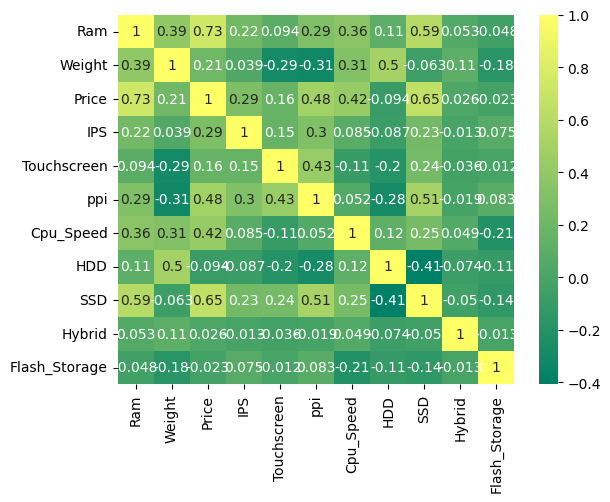

In [310]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='summer')

In [311]:
df.drop(columns=['Hybrid','Flash_Storage'],inplace=True)

In [312]:
df.sample(4)

,Company,TypeName,Cpu,Ram,Gpu,OpSys,Weight,Price,IPS,Touchscreen,ppi,Cpu_Speed,HDD,SSD
892,MSI,Gaming,Intel Core i7,8,Nvidia GeForce,Windows 10,2.20,95900,0,0,141.21,2.8,1000,128
18,Lenovo,Notebook,Intel Core i3,8,Nvidia GeForce,No OS,2.20,39900,0,0,141.21,2.4,1000,0
120,HP,Notebook,Intel Core i7,16,Nvidia GeForce,Windows 10,2.50,101700,0,0,127.34,1.8,0,512
862,HP,Netbook,Intel Core i7,8,Intel HD,Windows 10,1.26,118600,0,0,176.23,2.7,0,512


In [313]:
print(df['SSD'].value_counts())

SSD
256     479
0       425
128     166
512     125
1000     14
180       5
16        3
32        2
64        1
1024      1
768       1
240       1
8         1
Name: count, dtype: int64


In [314]:
df['SSD']=df['SSD'].replace(1024,1000)

In [315]:
print(df['SSD'].value_counts())

SSD
256     479
0       425
128     166
512     125
1000     15
180       5
16        3
32        2
64        1
768       1
240       1
8         1
Name: count, dtype: int64


<Axes: xlabel='SSD'>

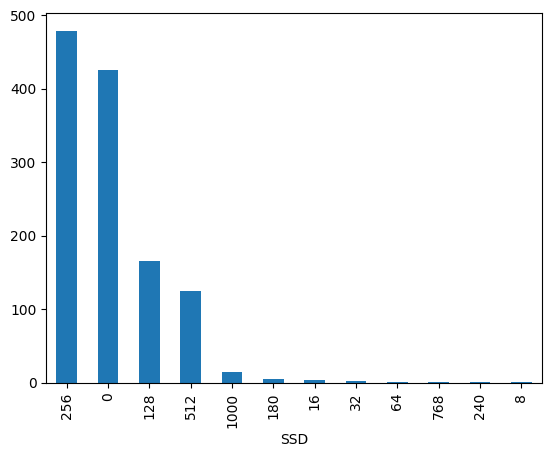

In [316]:
df['SSD'].value_counts().plot(kind='bar')

<Axes: xlabel='SSD', ylabel='Price'>

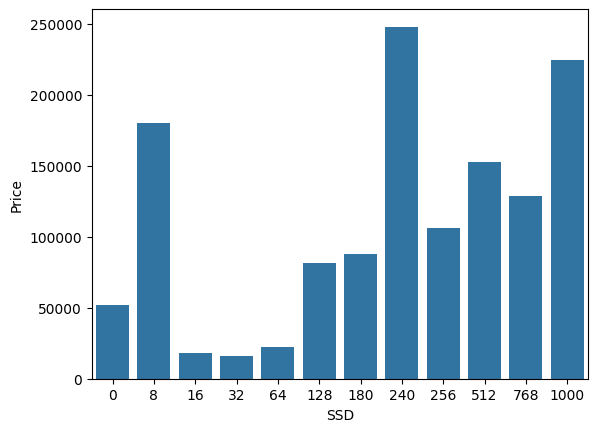

In [317]:
sns.barplot(x=df['SSD'],y=df['Price'],errorbar=None)

<Axes: xlabel='Price', ylabel='Density'>

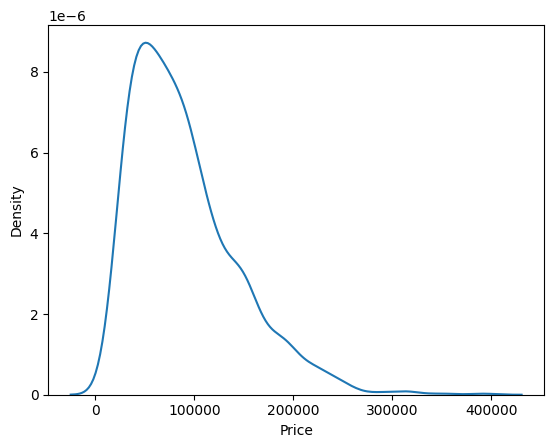

In [318]:
sns.kdeplot(df['Price'])

In [319]:
# right-skewed
# not normal

In [320]:
# 1.ignore the skewness and work on the data without any modifications
# 2.remove the outliers
# 3.make the data a little normal(for right skewed, we could apply log normalization)

<Axes: xlabel='Price', ylabel='Density'>

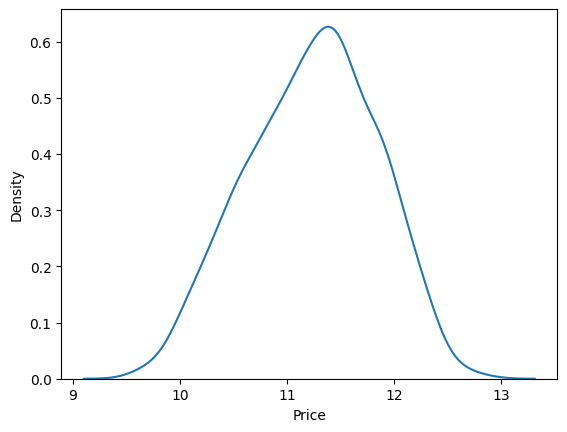

In [321]:
sns.kdeplot(np.log(df['Price']))

In [322]:
# we will chose option 1

<Axes: xlabel='Weight', ylabel='Count'>

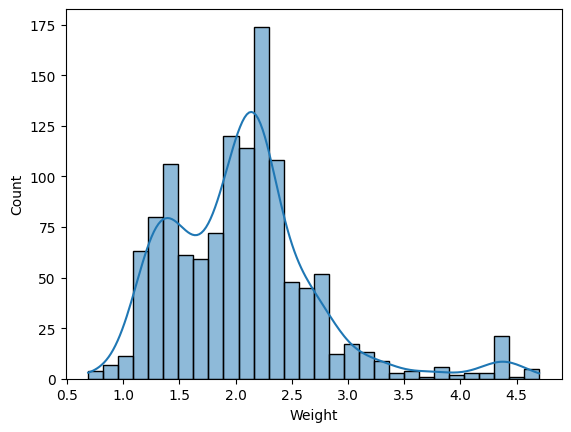

In [323]:
sns.histplot(df['Weight'],kde=True)

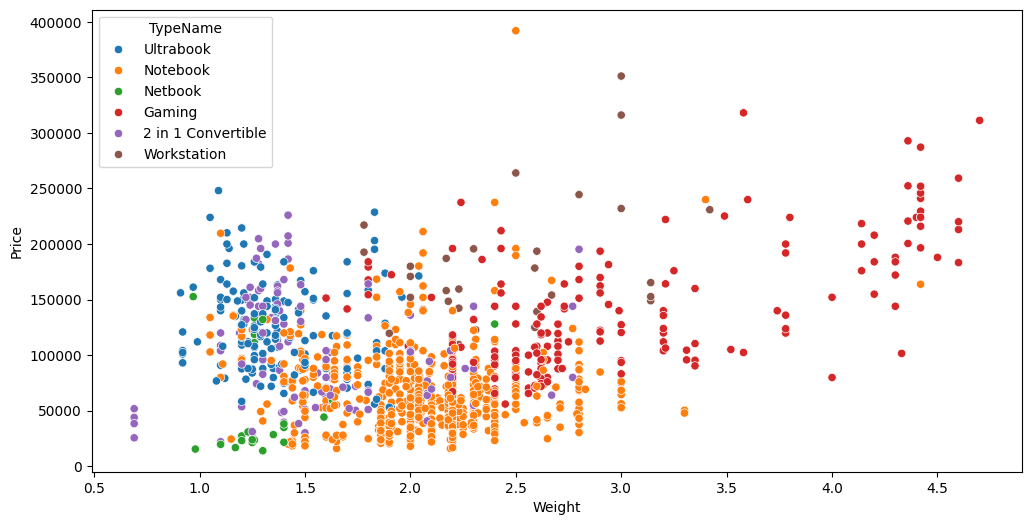

In [324]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=df['Weight'],y=df['Price'],hue=df['TypeName'])
plt.show()

<Axes: ylabel='Price'>

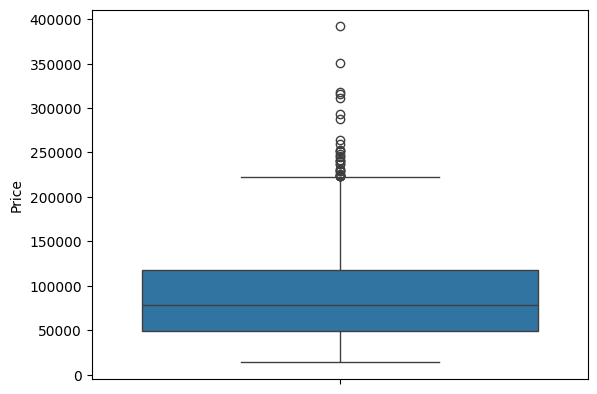

In [325]:
sns.boxplot(df['Price'])

In [326]:
df

,Company,TypeName,Cpu,Ram,Gpu,OpSys,Weight,Price,IPS,Touchscreen,ppi,Cpu_Speed,HDD,SSD
0,Apple,Ultrabook,Intel Core i5,8,Intel Iris,MacOS,1.37,107200,1,0,226.98,2.3,0,128
1,Apple,Ultrabook,Intel Core i5,8,Intel HD,MacOS,1.34,71900,0,0,127.68,1.8,0,0
2,HP,Notebook,Intel Core i5,8,Intel HD,No OS,1.86,46000,0,0,141.21,2.5,0,256
3,Apple,Ultrabook,Intel Core i7,16,AMD GPU,MacOS,1.83,203000,1,0,220.53,2.7,0,512
4,Apple,Ultrabook,Intel Core i5,8,Intel Iris,MacOS,1.37,144300,1,0,226.98,3.1,0,256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1219,Lenovo,2 in 1 Convertible,Intel Core i7,4,Intel HD,Windows 10,1.80,51000,1,1,157.35,2.5,0,128
1220,Lenovo,2 in 1 Convertible,Intel Core i7,16,Intel HD,Windows 10,1.30,119900,1,1,276.05,2.5,0,512
1221,Lenovo,Notebook,Intel Celeron,2,Intel HD,Windows 10,1.50,18300,0,0,111.94,1.6,0,0
1222,HP,Notebook,Intel Core i7,6,AMD GPU,Windows 10,2.19,61100,0,0,100.45,2.5,1000,0


In [327]:
df.to_csv('laptop_cleaned.csv',index=False)

In [328]:
# Machine Learning Model Creation

In [329]:
X = df.drop(columns=['Price'])
y = df['Price']

In [330]:
X.shape

(1224, 13)

In [331]:
X.ndim

2

In [332]:
y.shape

(1224,)

In [333]:
y.ndim

1

In [334]:
# we typically split the data into two parts.
# 1st part for training
# and the 2nd part for validation/testing

In [335]:
# model.fit(X_train,y_train)
# model.predict(X_test)
# y_test and y_pred will be compared and we will evaluate

In [336]:
from sklearn.model_selection import train_test_split

In [337]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.15, random_state=42)

In [338]:
X_train

,Company,TypeName,Cpu,Ram,Gpu,OpSys,Weight,IPS,Touchscreen,ppi,Cpu_Speed,HDD,SSD
240,Apple,Ultrabook,Intel Core i5,8,Intel Iris,MacOS,1.37,1,0,226.98,3.1,0,512
439,Lenovo,Notebook,Intel Core i5,8,Intel HD,Windows 10,1.65,0,0,157.35,2.5,0,256
192,Dell,Gaming,Intel Core i7,16,Nvidia GeForce,Windows 10,2.65,1,0,282.42,2.8,1000,512
218,Asus,Notebook,Intel Core i5,8,Nvidia GeForce,Windows 10,2.00,0,0,141.21,2.5,0,256
184,Dell,Notebook,Intel Core i7,8,AMD GPU,Windows 10,2.80,0,0,127.34,1.8,1000,128
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,HP,Notebook,Intel Core i3,4,Intel HD,No OS,1.86,0,0,100.45,2.0,1000,0
1095,HP,2 in 1 Convertible,Intel Core i7,8,Intel HD,Windows 10,1.48,0,1,220.84,2.6,0,256
1130,HP,Notebook,Intel Core i3,4,Intel HD,Windows 10,2.07,0,0,100.45,2.3,500,0
860,Lenovo,Ultrabook,Intel Core i7,8,Intel HD,Windows 10,1.13,1,0,157.35,2.7,0,0


In [339]:
y_train

240     163200
439     107600
192     147600
218      61500
184      86800
         ...  
1044     27700
1095    143900
1130     52000
860     163900
1126     61500
Name: Price, Length: 1040, dtype: int64

In [340]:
X.shape, X_train.shape, X_test.shape

((1224, 13), (1040, 13), (184, 13))

In [341]:
1040/1224, 184/1224

(0.8496732026143791, 0.1503267973856209)

In [342]:
from sklearn.linear_model import LinearRegression

In [343]:
# reg = LinearRegression()
# reg.fit(X_train,y_train)

# ValueError: could not convert string to float: 'Apple'
# Error because the 5 columns out of 13 input features are non numerical
# We need to convert them to numerical columns for this to work

In [344]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 1040 entries, 240 to 1126
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1040 non-null   str    
 1   TypeName     1040 non-null   str    
 2   Cpu          1040 non-null   str    
 3   Ram          1040 non-null   int64  
 4   Gpu          1040 non-null   str    
 5   OpSys        1040 non-null   str    
 6   Weight       1040 non-null   float64
 7   IPS          1040 non-null   int64  
 8   Touchscreen  1040 non-null   int64  
 9   ppi          1040 non-null   float64
 10  Cpu_Speed    1040 non-null   float64
 11  HDD          1040 non-null   int64  
 12  SSD          1040 non-null   int64  
dtypes: float64(3), int64(5), str(5)
memory usage: 161.1 KB


In [345]:
# Encoding : converting data from non-numeric to numeric
# 3 types
# LabelEncoder  : output columns
# OrdinalEncoder : only for ordinal data
# OneHotEncoder : for nominal data

In [346]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor, RandomForestRegressor

In [347]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [348]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [349]:
# step 1: Column Transformer ( OneHotencoding for 5 separate columns)
# step 2: apply ML algorithm(like linear regression, etc.)
# pipeline : step 1, step 2

In [350]:
df.sample()

,Company,TypeName,Cpu,Ram,Gpu,OpSys,Weight,Price,IPS,Touchscreen,ppi,Cpu_Speed,HDD,SSD
49,Lenovo,2 in 1 Convertible,Intel Atom,4,Intel HD,Linux/Chrome OS/Android,0.69,25500,1,1,224.17,1.44,0,0


In [351]:
ct_ohe = ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(drop='first'),[0,1,2,4,5])],
                           remainder='passthrough')
reg_model = LinearRegression()
pipe = Pipeline([('s1',ct_ohe),('s2',reg_model)])

pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)

print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",root_mean_squared_error(y_test,y_pred))

R2 Score: 0.7779679196830563
MAE: 17831.87276227075
RMSE: 25232.031538631407


In [352]:
# Ridge Regression
ct_ohe = ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(drop='first'),[0,1,2,4,5])],
                           remainder='passthrough')
reg_model = Ridge(alpha=1)
pipe = Pipeline([('s1',ct_ohe),('s2',reg_model)])

pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)

print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",root_mean_squared_error(y_test,y_pred))

R2 Score: 0.7808648982707933
MAE: 17874.78600582204
RMSE: 25066.882753227706


In [353]:
reg_model

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [354]:
# y = mx + c
# y = ax1 + bx2 + cx3 + dx4 + ... + z
# price = weight for CPU x CPU value + weight for RAM x RAM value + weight for SSD x SSD value +....

In [355]:
# noise
# overfitting

# Regularization
# Ridge Regression
    # adds a penalty for large weights
    # Disadvantage : even if a feature does not contribute to output, it does not remove the feature
# Lasso Regression
    # makes the unwanted co-efficients zero
    # also known as feature selection method

# Linear Regression is unrestrictive, ridge is controlled, and Lasso is selective

In [356]:
# Lasso Regression
ct_ohe = ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(drop='first'),[0,1,2,4,5])],
                           remainder='passthrough')
reg_model = Lasso(alpha=100)
pipe = Pipeline([('s1',ct_ohe),('s2',reg_model)])

pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)

print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",root_mean_squared_error(y_test,y_pred))

R2 Score: 0.7800764032777389
MAE: 18003.48425649351
RMSE: 25111.94026233333


In [357]:
# KNeighborsRegressor
ct_ohe = ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(drop='first'),[0,1,2,4,5])],
                           remainder='passthrough')
reg_model = KNeighborsRegressor(n_neighbors=5)
pipe = Pipeline([('s1',ct_ohe),('s2',reg_model)])

pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)

print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",root_mean_squared_error(y_test,y_pred))

R2 Score: 0.6609292629006426
MAE: 19282.391304347828
RMSE: 31180.96200094455


In [358]:
# DecisionTreeRegressor
ct_ohe = ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(drop='first'),[0,1,2,4,5])],
                           remainder='passthrough')
reg_model = DecisionTreeRegressor(max_depth=12, random_state=39)
pipe = Pipeline([('s1',ct_ohe),('s2',reg_model)])

pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)

print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",root_mean_squared_error(y_test,y_pred))

R2 Score: 0.7872321468883353
MAE: 16466.082843343072
RMSE: 24700.023163056263


In [359]:
# SVM (support vector machine)
ct_ohe = ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(drop='first'),[0,1,2,4,5])],
                           remainder='passthrough')
reg_model = SVR(C=100000000)
pipe = Pipeline([('s1',ct_ohe),('s2',reg_model)])

pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)

print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",root_mean_squared_error(y_test,y_pred))

R2 Score: 0.6467135942803367
MAE: 19721.46455230629
RMSE: 31827.887767552395


In [360]:
# Adaboost(Adaptive Boosting)
ct_ohe = ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(drop='first'),[0,1,2,4,5])],
                           remainder='passthrough')
reg_model = AdaBoostRegressor()
pipe = Pipeline([('s1',ct_ohe),('s2',reg_model)])

pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)

print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",root_mean_squared_error(y_test,y_pred))

R2 Score: 0.6349251551208166
MAE: 26387.376603476652
RMSE: 32354.545948866333


In [361]:
# Gradient Boosting Regressor
ct_ohe = ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(drop='first'),[0,1,2,4,5])],
                           remainder='passthrough')
reg_model = GradientBoostingRegressor()
pipe = Pipeline([('s1',ct_ohe),('s2',reg_model)])

pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)

print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",root_mean_squared_error(y_test,y_pred))

R2 Score: 0.8492344978577999
MAE: 14196.835712660893
RMSE: 20791.955838423055


In [362]:
# Random Forest
ct_ohe = ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(drop='first'),[0,1,2,4,5])],
                           remainder='passthrough')
reg_model = RandomForestRegressor(random_state=42,max_depth=12)
pipe = Pipeline([('s1',ct_ohe),('s2',reg_model)])

pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)

print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",root_mean_squared_error(y_test,y_pred))

R2 Score: 0.8382193322893141
MAE: 13707.229556872839
RMSE: 21538.11376413054


In [363]:
import pickle
pickle.dump(pipe,open('pipe.pkl','wb'))  #wb is write binary
pickle.dump(df,open('df.pkl','wb'))

In [364]:
df.sample()

,Company,TypeName,Cpu,Ram,Gpu,OpSys,Weight,Price,IPS,Touchscreen,ppi,Cpu_Speed,HDD,SSD
418,HP,Gaming,Intel Core i7,12,Nvidia GeForce,Windows 10,3.35,159900,0,0,127.34,2.8,1000,256


In [365]:
df['Company'].unique()

<ArrowStringArray>
['Apple', 'HP', 'Acer', 'Asus', 'Dell', 'Lenovo', 'MSI', 'Toshiba']
Length: 8, dtype: str

In [366]:
df['Cpu_Speed'].describe()

count    1224.000000
mean        2.311683
std         0.495780
min         0.900000
25%         2.000000
50%         2.500000
75%         2.700000
max         3.600000
Name: Cpu_Speed, dtype: float64

In [367]:
import sklearn
sklearn.__version__

'1.8.0'